# Exploratory Data Analysis

This notebook focuses on `Log K1` and uses variance-aware variable selection so the plotted metals and covariates actually show dispersion in the histograms. The plots are split into separate cells, and the histogram range is set to mean ± 4σ for each selected variable or grouped set of metal targets. Metal descriptors are sampled from the full table because they are constant within a single-metal Nd+++ subset.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("../data/41598_2020_71255_MOESM1_ESM.xlsx")
TARGET_COL = "Log K1"
METAL_COL = "Metal"
ND_LABEL = "Nd+++"
RANDOM_SEED = 42


def load_data() -> pd.DataFrame:
    df = pd.read_excel(DATA_PATH, sheet_name="lanthanides_final_dataset_for_M")
    df.columns = [column.strip() for column in df.columns]
    return df


def strip_values(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip()


def numeric_series(frame: pd.DataFrame, column: str) -> pd.Series:
    return pd.to_numeric(frame[column], errors="coerce").dropna()


def four_sigma_range(values: pd.Series) -> tuple[float, float]:
    values = pd.to_numeric(values, errors="coerce").dropna()
    if values.empty:
        return (0.0, 1.0)

    mean = float(values.mean())
    std = float(values.std(ddof=0))
    if not np.isfinite(std) or std <= 0:
        pad = max(abs(mean) * 0.1, 1.0)
    else:
        pad = max(4.0 * std, max(abs(mean) * 1e-6, 1e-6))

    lower = mean - pad
    upper = mean + pad
    if lower == upper:
        lower -= 1.0
        upper += 1.0
    return lower, upper


def high_variance_columns(frame: pd.DataFrame, candidates: list[str]) -> list[str]:
    selected = []
    for column in candidates:
        values = numeric_series(frame, column)
        if len(values) >= 2 and float(values.std(ddof=0)) > 0:
            selected.append(column)
    return selected


def sample_columns_with_variance(frame: pd.DataFrame, candidates: list[str], size: int, seed: int) -> list[str]:
    eligible = high_variance_columns(frame, candidates)
    if not eligible:
        return []
    rng = np.random.default_rng(seed)
    if len(eligible) <= size:
        return eligible[:size]
    return rng.choice(eligible, size=size, replace=False).tolist()


def sample_metals_with_logk1_variance(frame: pd.DataFrame, anchor_metal: str, sample_size: int, seed: int) -> list[str]:
    eligible_metals = []
    for metal in sorted(frame[METAL_COL].dropna().unique().tolist()):
        if metal == anchor_metal:
            continue
        values = numeric_series(frame.loc[frame[METAL_COL] == metal], TARGET_COL)
        if len(values) >= 2 and float(values.std(ddof=0)) > 0:
            eligible_metals.append(metal)

    rng = np.random.default_rng(seed)
    if len(eligible_metals) <= sample_size - 1:
        sampled_metals = eligible_metals
    else:
        sampled_metals = rng.choice(eligible_metals, size=sample_size - 1, replace=False).tolist()
    return [anchor_metal] + sampled_metals


def plot_logk1_histograms_for_metals(frame: pd.DataFrame, metals: list[str], title: str) -> None:
    common_range = four_sigma_range(frame.loc[frame[METAL_COL].isin(metals), TARGET_COL])
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, metal in zip(axes, metals):
        metal_values = numeric_series(frame.loc[frame[METAL_COL] == metal], TARGET_COL)
        ax.hist(
            metal_values,
            bins=20,
            range=common_range,
            color="#4C72B0",
            edgecolor="white",
            alpha=0.9,
        )
        ax.set_title(metal)
        ax.set_xlabel("log K1")
        ax.set_ylabel("Count")

    for ax in axes[len(metals):]:
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_histogram_grid(frame: pd.DataFrame, columns: list[str], title: str, color: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
    axes = axes.ravel()

    for ax, column in zip(axes, columns):
        values = numeric_series(frame, column)
        if values.empty or values.nunique(dropna=True) < 2:
            ax.text(0.5, 0.5, "Insufficient variance", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(column)
            ax.set_axis_off()
            continue

        ax.hist(
            values,
            bins=20,
            range=four_sigma_range(values),
            color=color,
            edgecolor="white",
            alpha=0.9,
        )
        ax.set_title(column)
        ax.set_ylabel("Count")

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


df = load_data()
df[METAL_COL] = strip_values(df[METAL_COL])
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df[METAL_COL] = df[METAL_COL].str.strip()
nd_df = df[df[METAL_COL] == ND_LABEL].copy()
rare_earth_metals = sorted(df[METAL_COL].dropna().unique().tolist())
selected_metals = sample_metals_with_logk1_variance(df, ND_LABEL, sample_size=4, seed=RANDOM_SEED)

metal_descriptor_cols = [column for column in df.columns if column.endswith("_metal") or "_metal" in column]
medium_descriptor_cols = [column for column in df.columns if "_medium" in column]
condition_cols = [column for column in ["Temperature (K)", "Concentration (M)"] if column in df.columns]

selected_metal_descriptor_cols = sample_columns_with_variance(df, metal_descriptor_cols, size=4, seed=RANDOM_SEED)
selected_medium_descriptor_cols = sample_columns_with_variance(nd_df, medium_descriptor_cols, size=3, seed=RANDOM_SEED)
selected_condition_cols = sample_columns_with_variance(nd_df, condition_cols, size=2, seed=RANDOM_SEED)


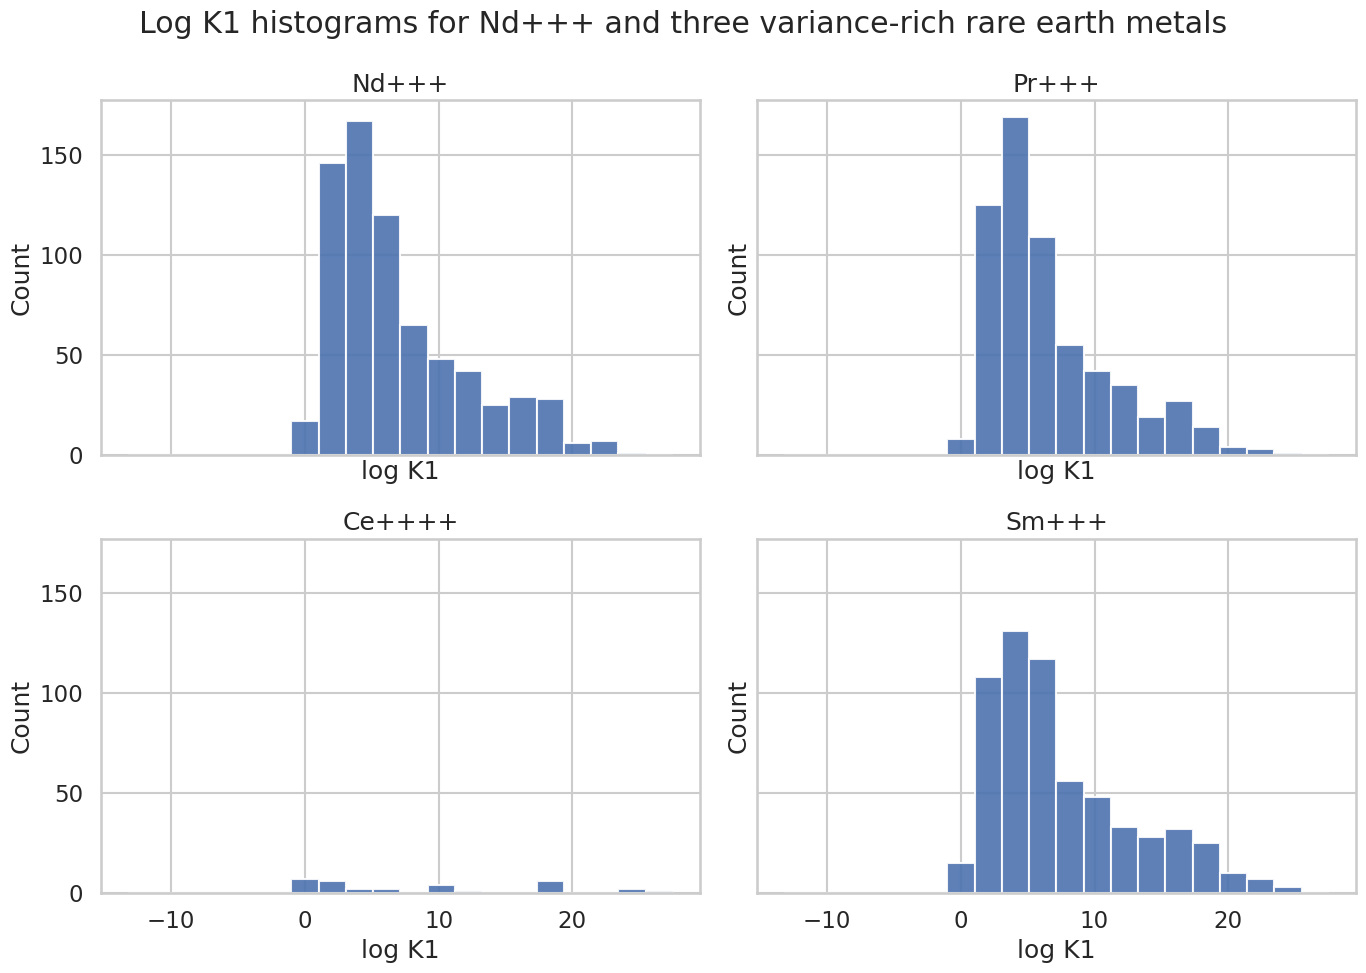

In [2]:
plot_logk1_histograms_for_metals(
    frame=df,
    metals=selected_metals,
    title="Log K1 histograms for Nd+++ and three variance-rich rare earth metals",
)


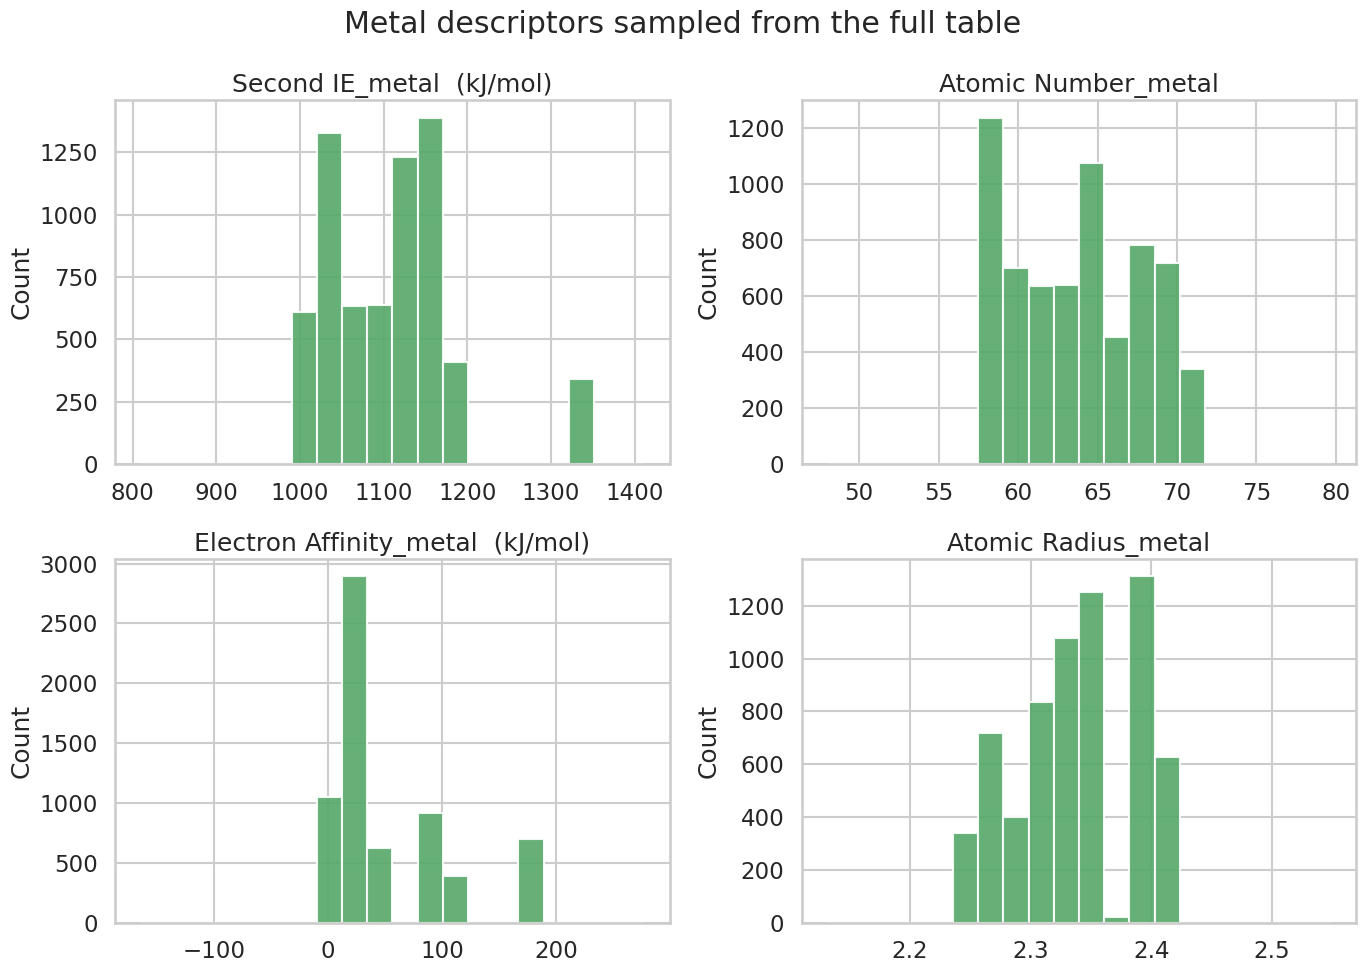

In [3]:
plot_histogram_grid(
    frame=df,
    columns=selected_metal_descriptor_cols,
    title="Metal descriptors sampled from the full table",
    color="#55A868",
)


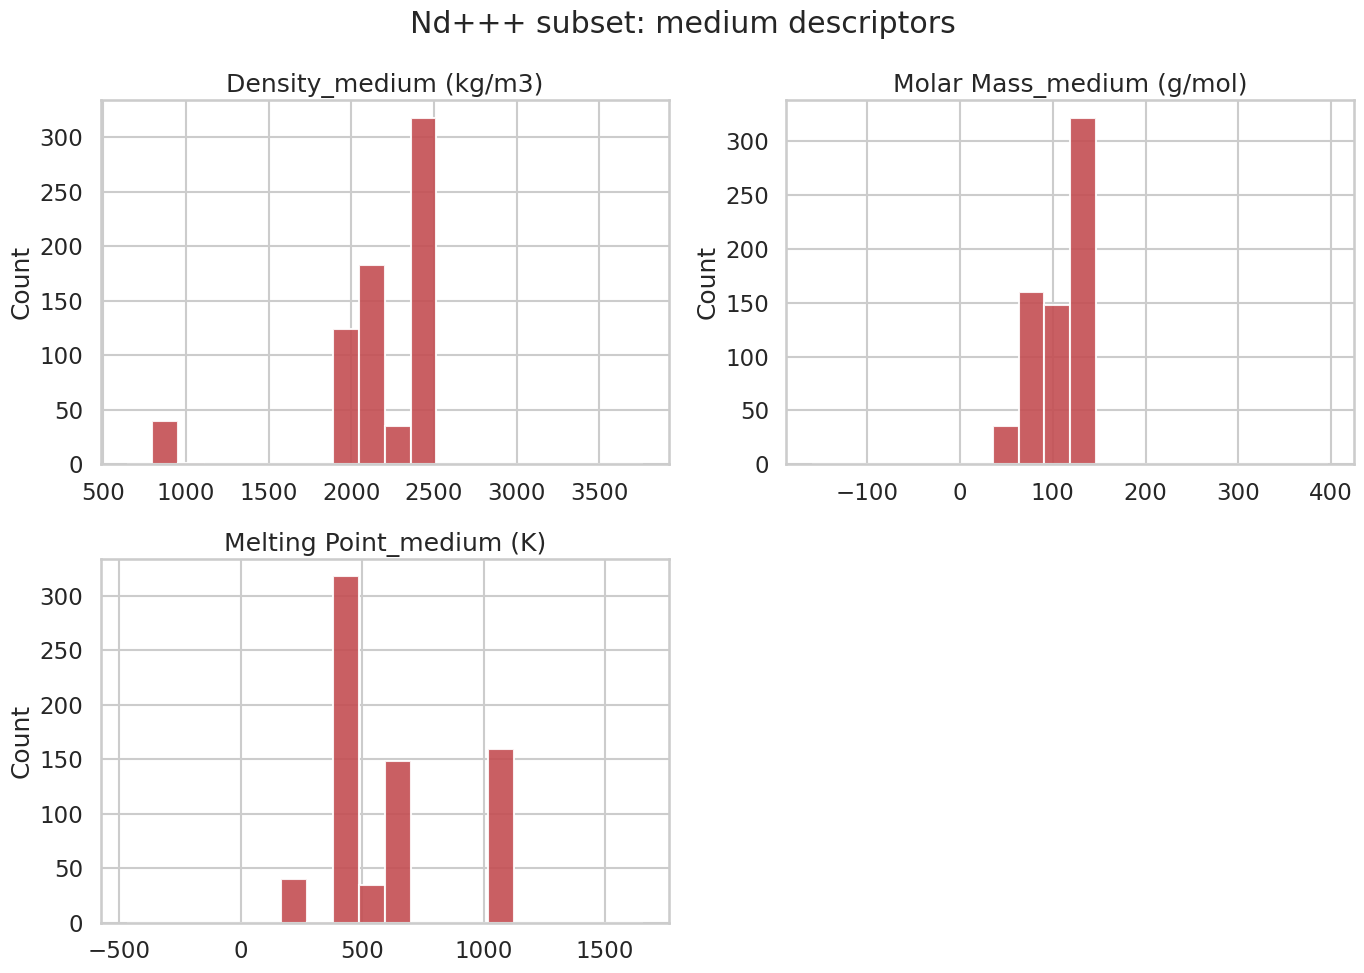

In [4]:
plot_histogram_grid(
    frame=nd_df,
    columns=selected_medium_descriptor_cols,
    title="Nd+++ subset: medium descriptors",
    color="#C44E52",
)


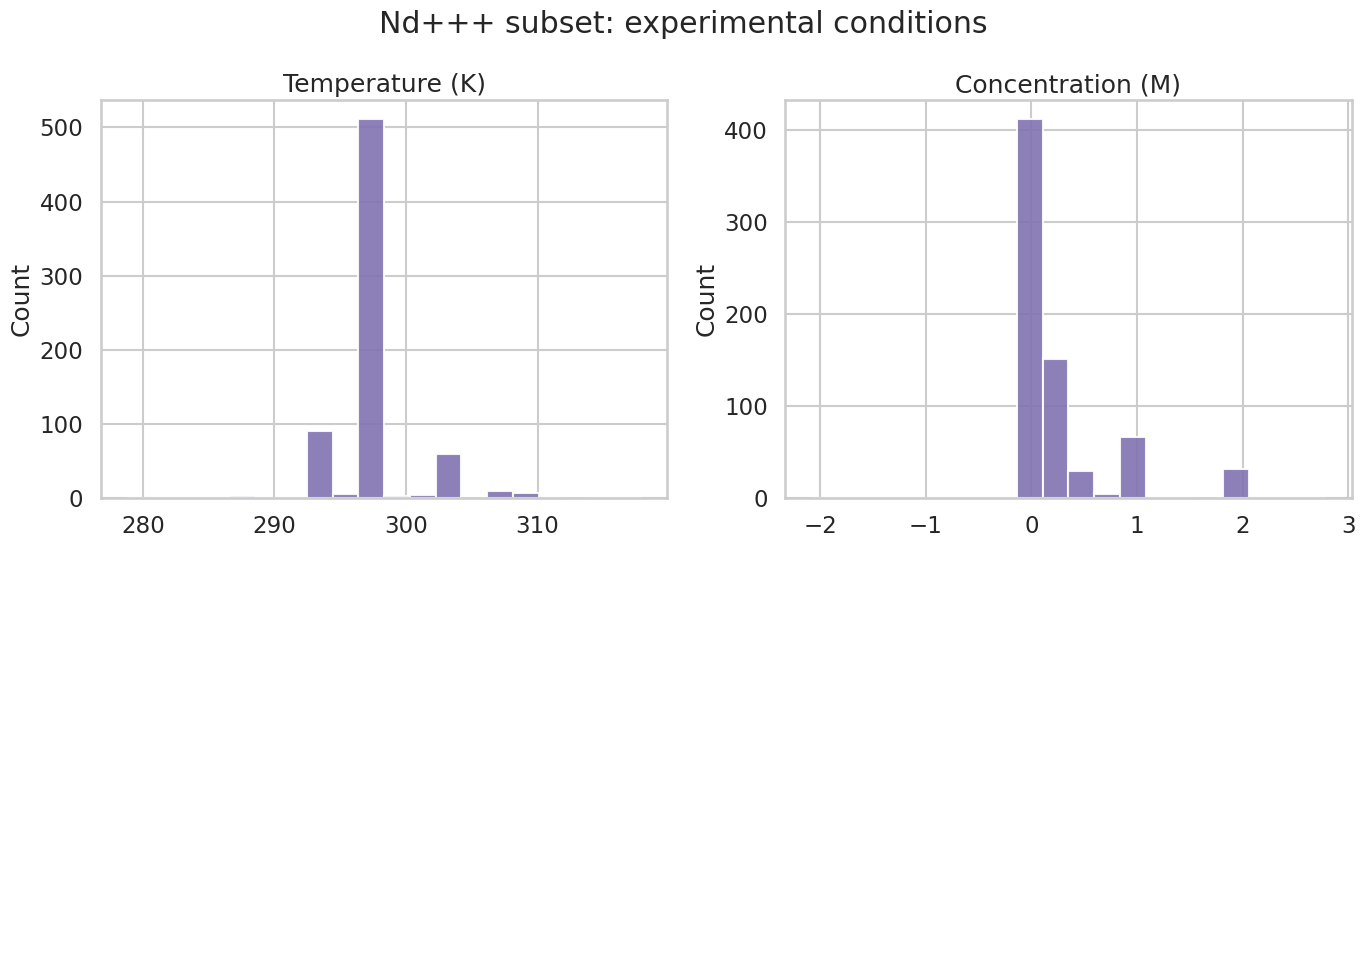

In [5]:
plot_histogram_grid(
    frame=nd_df,
    columns=selected_condition_cols,
    title="Nd+++ subset: experimental conditions",
    color="#8172B2",
)
